# Part 1 — What Types of Apps to BUILD (Original Ideas)

**Goal:** Find app categories where demand is proven but no one has nailed the execution.  
These are the best opportunities to build something *new and better* — not a clone.

**Signals we look for:**
- High installs (demand exists) but low average rating (execution is bad across the board)
- Categories growing in 2026 scraped data (new apps gaining traction quickly)
- Niches with few apps but high average installs per app (low competition, high demand)
- Categories where the rating distribution is wide — top apps are mediocre, no clear winner

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

TAPIVE_RELATIVE = 'data_my_copy/google-play-dataset-by-tapivedotcom.csv/google-play-dataset-by-tapivedotcom.csv'
APPS26_RELATIVE = 'data/scraped_2026/apps.csv'

def find_project_root():
    candidates = [Path().resolve()]
    p = Path().resolve()
    for _ in range(10):
        p = p.parent
        candidates.append(p)
    for c in candidates:
        if (c / TAPIVE_RELATIVE).exists():
            return c
    raise FileNotFoundError(f'Cannot find Tapive CSV. Searched: {candidates}')

ROOT = find_project_root()
TAPIVE_PATH = str(ROOT / TAPIVE_RELATIVE)
APPS_2026_PATH = str(ROOT / APPS26_RELATIVE)
print(f'Project root: {ROOT}')

print('Loading datasets...')
tap = pd.read_csv(TAPIVE_PATH, low_memory=False)
apps26 = pd.read_csv(APPS_2026_PATH, low_memory=False)
print(f'Tapive: {len(tap):,} apps')
print(f'2026 scraped: {len(apps26):,} apps')

Project root: D:\Projects\play-store-analysis-github
Loading datasets...


Tapive: 3,451,063 apps
2026 scraped: 11,176 apps


In [2]:
# --- Clean Tapive dataset ---
tap['minInstalls'] = pd.to_numeric(tap['minInstalls'], errors='coerce')
tap['score'] = pd.to_numeric(tap['score'], errors='coerce')
tap['ratings'] = pd.to_numeric(tap['ratings'], errors='coerce')

# Keep only apps with meaningful data
tap_clean = tap.dropna(subset=['genre', 'score', 'minInstalls']).copy()
tap_clean = tap_clean[tap_clean['minInstalls'] >= 1000]   # at least 1k installs
tap_clean = tap_clean[tap_clean['score'] > 0]
print(f'Tapive cleaned: {len(tap_clean):,} apps')

# --- Clean 2026 dataset ---
apps26['min_installs'] = pd.to_numeric(apps26['min_installs'], errors='coerce')
apps26['score'] = pd.to_numeric(apps26['score'], errors='coerce')
apps26['ratings'] = pd.to_numeric(apps26['ratings'], errors='coerce')

apps26_clean = apps26.dropna(subset=['genre', 'score', 'min_installs']).copy()
apps26_clean = apps26_clean[apps26_clean['min_installs'] >= 1000]
apps26_clean = apps26_clean[apps26_clean['score'] > 0]
print(f'2026 cleaned: {len(apps26_clean):,} apps')

Tapive cleaned: 411,453 apps


2026 cleaned: 7,875 apps


## Signal 1 — High Demand, Low Quality (Tapive 3.4M)
Categories with large install base but the average rating is poor (< 3.8).  
If everyone in the category is bad, a well-built app wins easily.

In [3]:
cat_stats = tap_clean.groupby('genre').agg(
    app_count=('appId', 'count'),
    avg_score=('score', 'mean'),
    median_score=('score', 'median'),
    total_installs=('minInstalls', 'sum'),
    avg_installs=('minInstalls', 'mean'),
    pct_under_3=('score', lambda x: (x < 3.0).mean() * 100)
).reset_index()

cat_stats = cat_stats[cat_stats['app_count'] >= 500]  # only meaningful categories
cat_stats = cat_stats.sort_values('avg_installs', ascending=False)

# High demand = avg_installs in top 50%, low quality = avg_score < 3.8
median_installs = cat_stats['avg_installs'].median()
underserved = cat_stats[
    (cat_stats['avg_installs'] >= median_installs) &
    (cat_stats['avg_score'] < 3.8)
].sort_values('avg_installs', ascending=False)

print(f'Underserved categories (high demand, low quality): {len(underserved)}')
print(underserved[['genre','app_count','avg_score','avg_installs','pct_under_3']].to_string(index=False))

Underserved categories (high demand, low quality): 3
                  genre  app_count  avg_score  avg_installs  pct_under_3
Video Players & Editors       4598   3.787856  5.440888e+06    16.246194
             Simulation      13615   3.743974  1.082104e+06    14.131473
      Maps & Navigation       4150   3.776330  7.853316e+05    14.361446


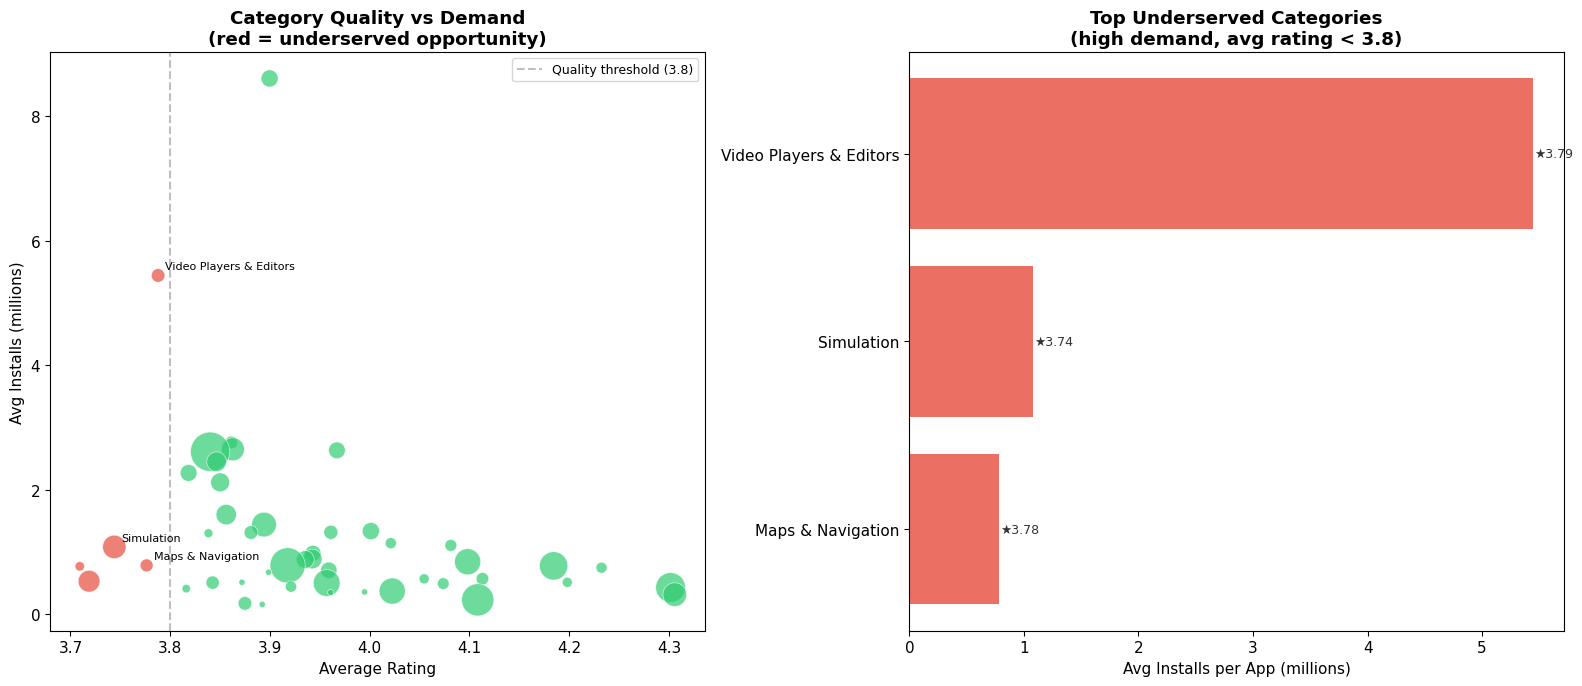

Saved: p1_underserved_categories.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: scatter — avg_installs vs avg_score, bubble = app_count
ax = axes[0]
sizes = np.clip(cat_stats['app_count'] / cat_stats['app_count'].max() * 800, 20, 800)
colors = ['#e74c3c' if s < 3.8 else '#2ecc71' for s in cat_stats['avg_score']]
scatter = ax.scatter(
    cat_stats['avg_score'], 
    cat_stats['avg_installs'] / 1e6,
    s=sizes, c=colors, alpha=0.7, edgecolors='white', linewidth=0.5
)
ax.axvline(3.8, color='gray', linestyle='--', alpha=0.5, label='Quality threshold (3.8)')
for _, row in underserved.head(8).iterrows():
    ax.annotate(row['genre'], (row['avg_score'], row['avg_installs']/1e6),
                fontsize=8, ha='left', va='bottom',
                xytext=(5, 3), textcoords='offset points')
ax.set_xlabel('Average Rating')
ax.set_ylabel('Avg Installs (millions)')
ax.set_title('Category Quality vs Demand\n(red = underserved opportunity)', fontweight='bold')
ax.legend(fontsize=9)

# Right: top underserved categories bar chart
ax2 = axes[1]
top_u = underserved.head(12).sort_values('avg_installs')
bars = ax2.barh(top_u['genre'], top_u['avg_installs']/1e6, color='#e74c3c', alpha=0.8)
for bar, score in zip(bars, top_u['avg_score']):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'★{score:.2f}', va='center', fontsize=9, color='#333')
ax2.set_xlabel('Avg Installs per App (millions)')
ax2.set_title('Top Underserved Categories\n(high demand, avg rating < 3.8)', fontweight='bold')

plt.tight_layout()
plt.savefig('p1_underserved_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: p1_underserved_categories.png')

## Signal 2 — Low Competition, High Demand (Niche Goldmines)
Categories with fewer apps but high average installs per app.  
Less competition, but users are clearly hungry for what's there.

In [5]:
# Installs per app = proxy for demand-to-supply ratio
niche = cat_stats.copy()
niche['demand_supply_ratio'] = niche['avg_installs'] / (niche['app_count'] ** 0.5)  # normalized
niche_sorted = niche.sort_values('demand_supply_ratio', ascending=False)

print('=== TOP NICHES: High demand-to-supply ratio ===')
print(niche_sorted[['genre','app_count','avg_installs','avg_score','demand_supply_ratio']].head(20).to_string(index=False))

=== TOP NICHES: High demand-to-supply ratio ===
                  genre  app_count  avg_installs  avg_score  demand_supply_ratio
          Communication       7303  8.604805e+06   3.899666        100690.935600
Video Players & Editors       4598  5.440888e+06   3.787856         80238.965273
                 Racing       4045  2.759512e+06   3.861197         43388.346548
                 Social       6947  2.633078e+06   3.967131         31591.125726
                  Music       1968  1.301343e+06   3.838323         29334.547864
         Travel & Local       7052  2.270010e+06   3.818409         27031.592484
                 Comics        710  6.748099e+05   3.898563         25325.162736
                 Action       9621  2.449931e+06   3.846470         24977.202693
           Productivity      13205  2.649936e+06   3.862802         23060.368660
            Photography       8912  2.118682e+06   3.850062         22442.855816
                Weather       3093  1.141645e+06   4.021164  

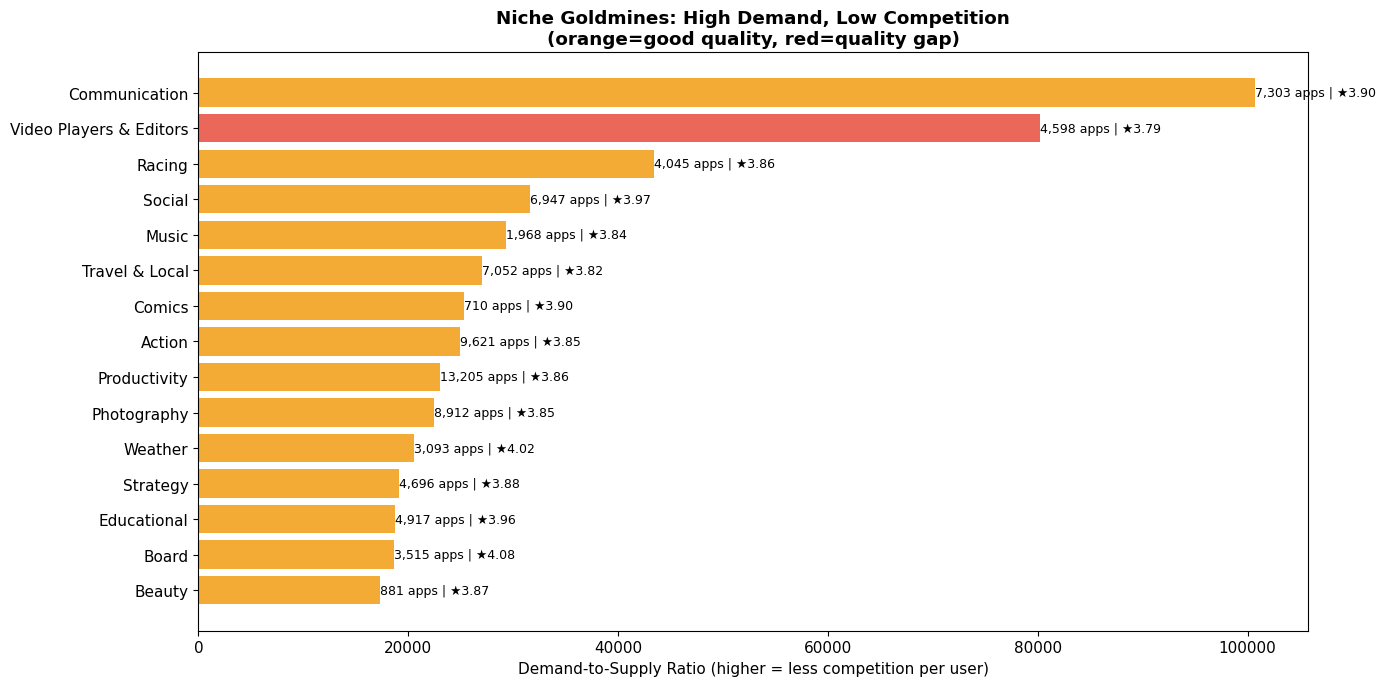

In [6]:
fig, ax = plt.subplots(figsize=(14, 7))
top_niche = niche_sorted.head(15).sort_values('demand_supply_ratio')
colors_n = ['#f39c12' if s >= 3.8 else '#e74c3c' for s in top_niche['avg_score']]
bars = ax.barh(top_niche['genre'], top_niche['demand_supply_ratio'], color=colors_n, alpha=0.85)
for bar, row in zip(bars, top_niche.itertuples()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{row.app_count:,} apps | ★{row.avg_score:.2f}',
             va='center', fontsize=9)
ax.set_xlabel('Demand-to-Supply Ratio (higher = less competition per user)')
ax.set_title('Niche Goldmines: High Demand, Low Competition\n(orange=good quality, red=quality gap)', fontweight='bold')
plt.tight_layout()
plt.savefig('p1_niche_goldmines.png', dpi=150, bbox_inches='tight')
plt.show()

## Signal 3 — Growing Categories in 2026 (Fresh Demand)
From the 2026 scraped data: categories where new apps are getting installs fast.  
These are categories on the rise right now.

In [7]:
growing = apps26_clean.groupby('genre').agg(
    app_count=('app_id', 'count'),
    avg_score=('score', 'mean'),
    avg_installs=('min_installs', 'mean'),
    total_installs=('min_installs', 'sum'),
    avg_reviews=('reviews', 'mean'),
).reset_index()

growing = growing[growing['app_count'] >= 10]
growing['installs_per_app'] = growing['total_installs'] / growing['app_count']
growing_sorted = growing.sort_values('installs_per_app', ascending=False)

print('=== 2026 Category Rankings by Installs/App ===')
print(growing_sorted[['genre','app_count','avg_score','installs_per_app','total_installs']].head(25).to_string(index=False))

=== 2026 Category Rankings by Installs/App ===
                  genre  app_count  avg_score  installs_per_app  total_installs
          Communication        118   4.190006      6.819408e+08    8.046902e+10
        Auto & Vehicles         22   4.303001      4.624960e+08    1.017491e+10
                 Social        117   4.078857      1.906301e+08    2.230372e+10
Video Players & Editors        158   4.141356      1.700585e+08    2.686924e+10
                  Tools        542   4.170673      1.514398e+08    8.208037e+10
                 Arcade         69   4.363681      1.154299e+08    7.964665e+09
                 Racing         45   4.344742      1.102478e+08    4.961150e+09
         Travel & Local        194   4.226398      7.924505e+07    1.537354e+10
                 Action        146   4.297789      7.850062e+07    1.146109e+10
           Productivity        656   4.264256      7.665730e+07    5.028719e+10
            Photography        264   4.228701      7.259725e+07    1.9165

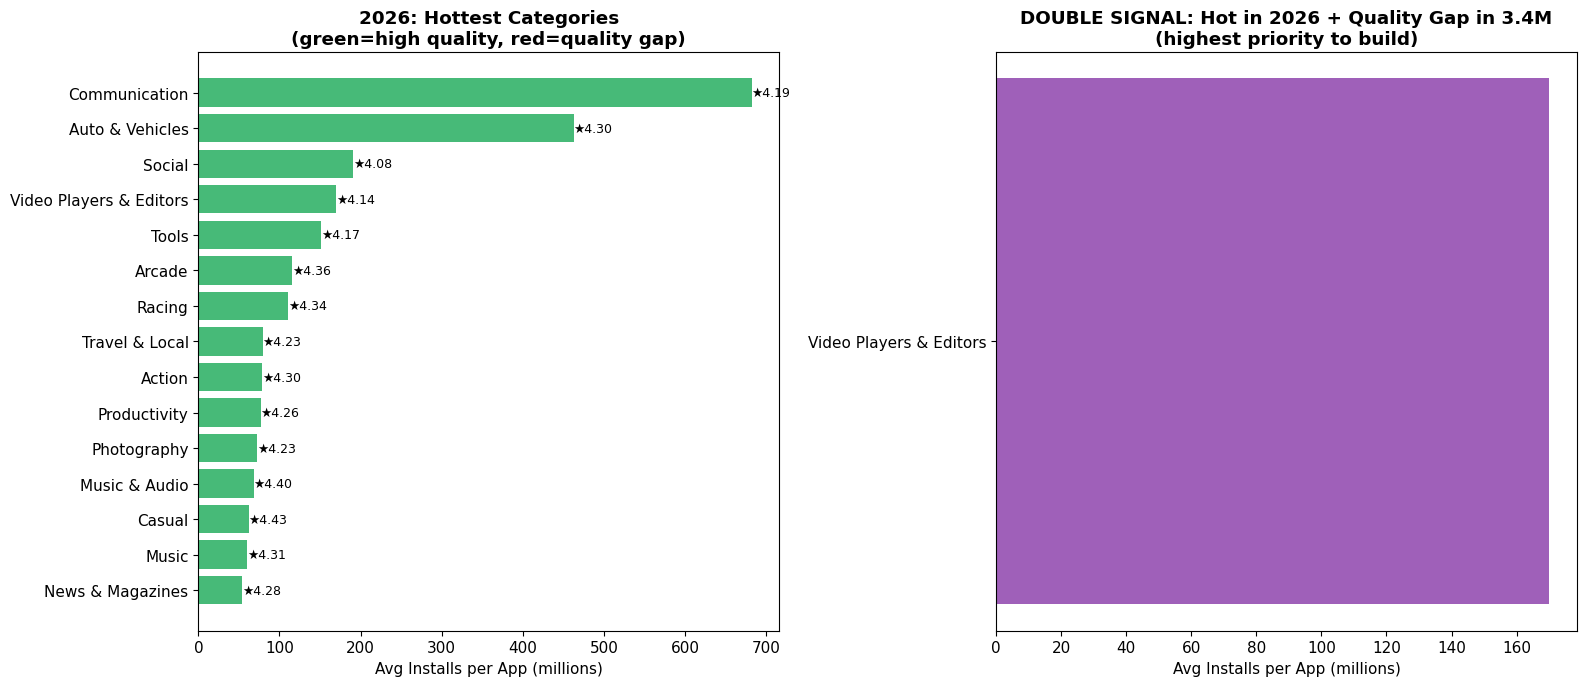

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax1 = axes[0]
top_g = growing_sorted.head(15).sort_values('installs_per_app')
c1 = ['#27ae60' if s >= 4.0 else '#f39c12' if s >= 3.5 else '#e74c3c' for s in top_g['avg_score']]
bars = ax1.barh(top_g['genre'], top_g['installs_per_app']/1e6, color=c1, alpha=0.85)
for bar, row in zip(bars, top_g.itertuples()):
    ax1.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'★{row.avg_score:.2f}', va='center', fontsize=9)
ax1.set_xlabel('Avg Installs per App (millions)')
ax1.set_title('2026: Hottest Categories\n(green=high quality, red=quality gap)', fontweight='bold')

ax2 = axes[1]
# Cross-reference: categories that are hot in 2026 AND have quality gap in Tapive
hot_2026 = set(growing_sorted.head(20)['genre'].str.strip())
underserved_set = set(underserved['genre'].str.strip())
double_signal = hot_2026 & underserved_set

ds_data = growing_sorted[growing_sorted['genre'].isin(double_signal)]
if len(ds_data) > 0:
    ds_data = ds_data.sort_values('installs_per_app')
    ax2.barh(ds_data['genre'], ds_data['installs_per_app']/1e6, color='#8e44ad', alpha=0.85)
    ax2.set_xlabel('Avg Installs per App (millions)')
    ax2.set_title('DOUBLE SIGNAL: Hot in 2026 + Quality Gap in 3.4M\n(highest priority to build)', fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'No overlap found\n(adjust thresholds)', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Double Signal Categories')

plt.tight_layout()
plt.savefig('p1_growing_categories.png', dpi=150, bbox_inches='tight')
plt.show()

## Signal 4 — Rating Distribution Analysis (No Clear Winner)
In some categories, even the best apps are only 3.5 stars.  
High standard deviation in ratings = no dominant player = open field.

In [9]:
spread = tap_clean.groupby('genre').agg(
    app_count=('appId', 'count'),
    avg_score=('score', 'mean'),
    score_std=('score', 'std'),
    max_score=('score', 'max'),
    p75_score=('score', lambda x: x.quantile(0.75)),
    avg_installs=('minInstalls', 'mean'),
).reset_index()

spread = spread[spread['app_count'] >= 200]
# Low p75 = even the better apps are mediocre
spread['opportunity_score'] = (
    (spread['avg_installs'] / spread['avg_installs'].max()) * 0.5 +
    ((4.5 - spread['p75_score']) / 4.5) * 0.5
)
spread_sorted = spread.sort_values('opportunity_score', ascending=False)

print('=== Categories where even top apps are mediocre ===')
print(spread_sorted[['genre','app_count','avg_score','p75_score','avg_installs','opportunity_score']].head(20).to_string(index=False))

=== Categories where even top apps are mediocre ===
                  genre  app_count  avg_score  p75_score  avg_installs  opportunity_score
          Communication       7303   3.899666       4.41  8.604805e+06           0.510000
Video Players & Editors       4598   3.787856       4.40  5.440888e+06           0.327265
                 Racing       4045   3.861197       4.27  2.759512e+06           0.185903
           Productivity      13205   3.862802       4.41  2.649936e+06           0.163980
                  Tools      38481   3.840036       4.40  2.610255e+06           0.162785
                 Action       9621   3.846470       4.33  2.449931e+06           0.161247
                 Social       6947   3.967131       4.52  2.633078e+06           0.150778
         Travel & Local       7052   3.818409       4.41  2.270010e+06           0.141904
            Photography       8912   3.850062       4.43  2.118682e+06           0.130888
                 Arcade      10318   3.856169   

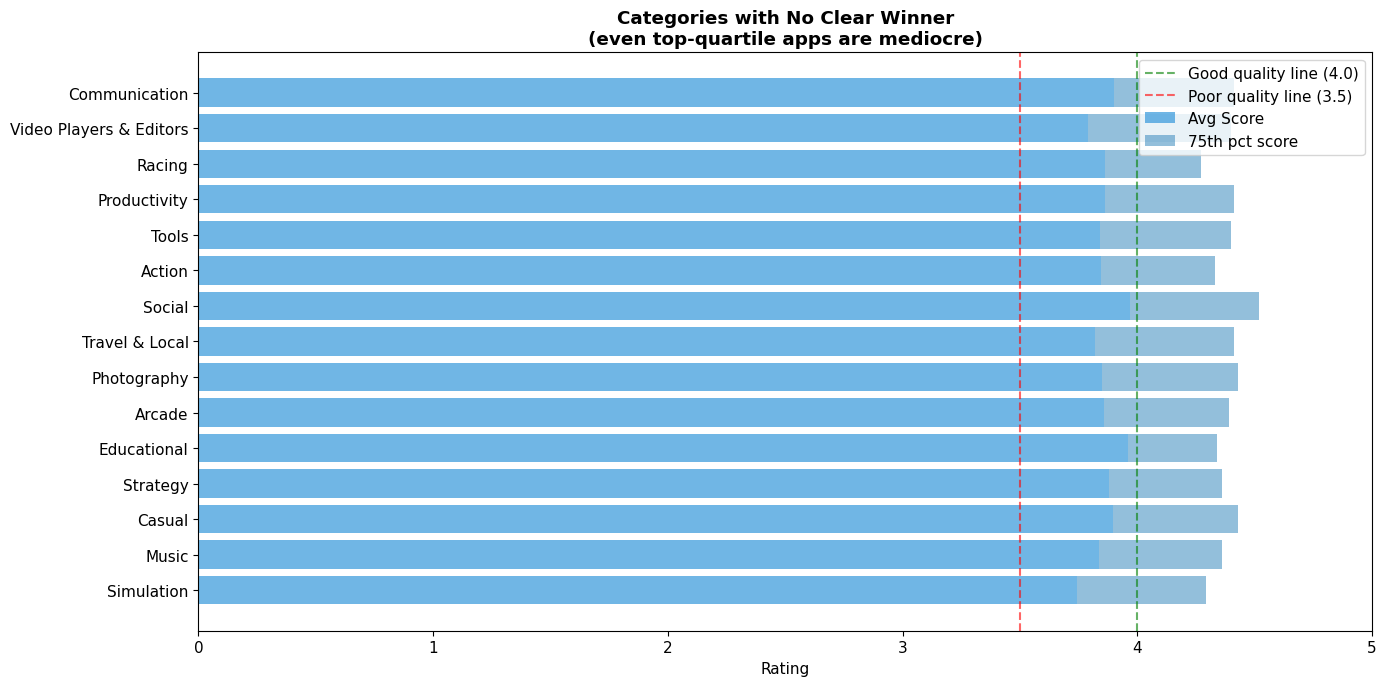

In [10]:
fig, ax = plt.subplots(figsize=(14, 7))
top_spread = spread_sorted.head(15).sort_values('opportunity_score')
x = np.arange(len(top_spread))
ax.barh(top_spread['genre'], top_spread['avg_score'], label='Avg Score', color='#3498db', alpha=0.7)
ax.barh(top_spread['genre'], top_spread['p75_score'] - top_spread['avg_score'],
        left=top_spread['avg_score'], label='75th pct score', color='#2980b9', alpha=0.5)
ax.axvline(4.0, color='green', linestyle='--', alpha=0.6, label='Good quality line (4.0)')
ax.axvline(3.5, color='red', linestyle='--', alpha=0.6, label='Poor quality line (3.5)')
ax.set_xlabel('Rating')
ax.set_title('Categories with No Clear Winner\n(even top-quartile apps are mediocre)', fontweight='bold')
ax.legend()
ax.set_xlim(0, 5)
plt.tight_layout()
plt.savefig('p1_no_clear_winner.png', dpi=150, bbox_inches='tight')
plt.show()

## Final Recommendation — Top Categories to Build Original Apps

In [11]:
# Combine all signals into a single recommendation score
all_genres = set(cat_stats['genre']) | set(growing['genre']) | set(spread['genre'])

rec = cat_stats[['genre','avg_score','avg_installs','app_count']].copy()

# Normalize signals
rec['install_score'] = (rec['avg_installs'] - rec['avg_installs'].min()) / \
                       (rec['avg_installs'].max() - rec['avg_installs'].min())
rec['quality_gap'] = 1 - (rec['avg_score'] - 1) / 4  # lower quality = higher gap score

# 2026 signal — is this category hot right now?
growing_installs = growing.set_index('genre')['installs_per_app'].to_dict()
max_growing = max(growing_installs.values()) if growing_installs else 1
rec['growth_2026'] = rec['genre'].map(
    {g: v/max_growing for g, v in growing_installs.items()}
).fillna(0)

rec['FINAL_SCORE'] = (
    rec['install_score'] * 0.35 +
    rec['quality_gap'] * 0.40 +
    rec['growth_2026'] * 0.25
)

rec_sorted = rec.sort_values('FINAL_SCORE', ascending=False).head(20)

print('\n' + '='*70)
print('TOP CATEGORIES TO BUILD ORIGINAL APPS (ranked by opportunity)')
print('='*70)
for i, row in enumerate(rec_sorted.itertuples(), 1):
    print(f"{i:2}. {row.genre:<30} | Score: {row.FINAL_SCORE:.3f} | "
          f"Avg Rating: {row.avg_score:.2f} | Avg Installs: {row.avg_installs/1e6:.1f}M")


TOP CATEGORIES TO BUILD ORIGINAL APPS (ranked by opportunity)
 1. Communication                  | Score: 0.710 | Avg Rating: 3.90 | Avg Installs: 8.6M
 2. Video Players & Editors        | Score: 0.402 | Avg Rating: 3.79 | Avg Installs: 5.4M
 3. Auto & Vehicles                | Score: 0.324 | Avg Rating: 3.71 | Avg Installs: 0.8M
 4. Social                         | Score: 0.276 | Avg Rating: 3.97 | Avg Installs: 2.6M
 5. Tools                          | Score: 0.273 | Avg Rating: 3.84 | Avg Installs: 2.6M
 6. Racing                         | Score: 0.262 | Avg Rating: 3.86 | Avg Installs: 2.8M
 7. Productivity                   | Score: 0.245 | Avg Rating: 3.86 | Avg Installs: 2.6M
 8. Action                         | Score: 0.239 | Avg Rating: 3.85 | Avg Installs: 2.4M
 9. Travel & Local                 | Score: 0.235 | Avg Rating: 3.82 | Avg Installs: 2.3M
10. Photography                    | Score: 0.223 | Avg Rating: 3.85 | Avg Installs: 2.1M
11. Arcade                         | 

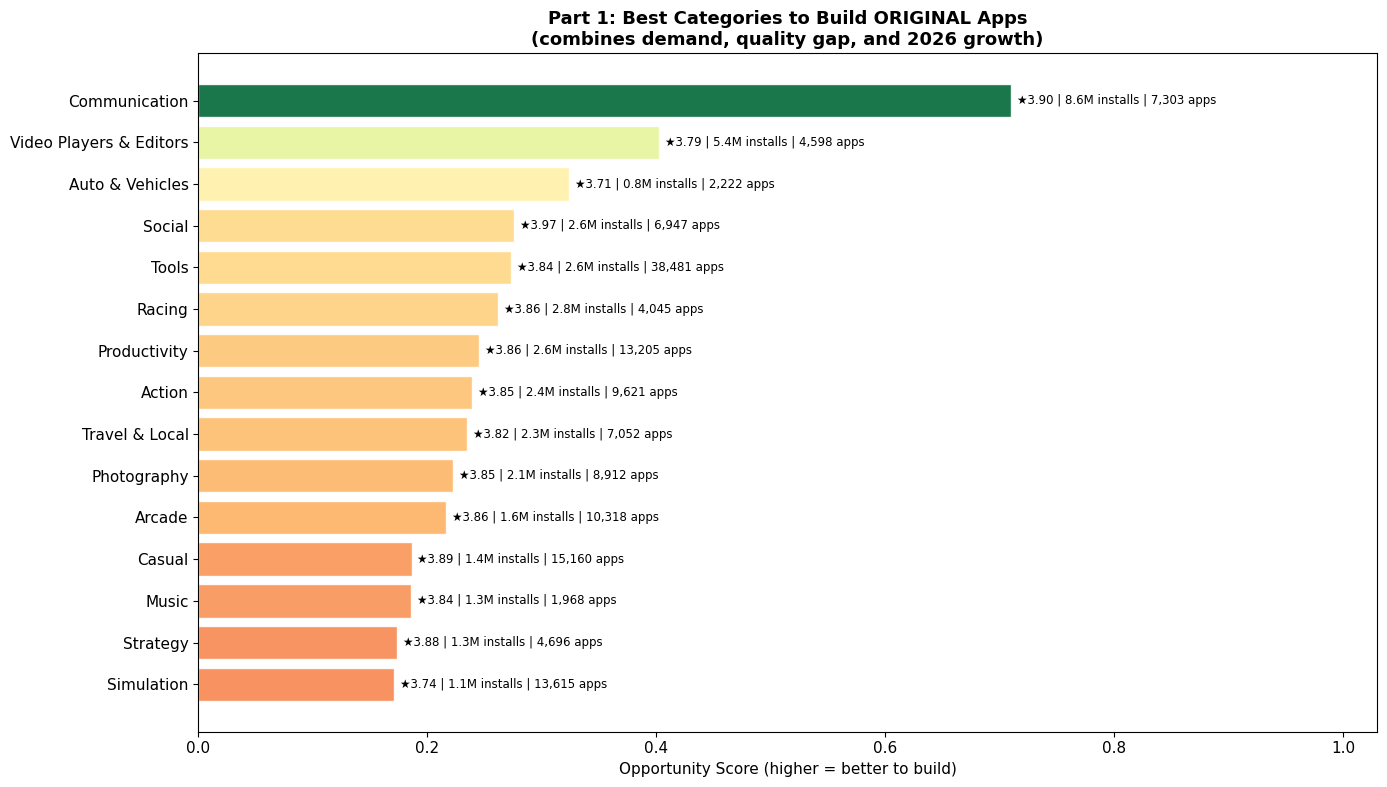


All Part 1 charts saved.


In [12]:
fig, ax = plt.subplots(figsize=(14, 8))
top_rec = rec_sorted.head(15).sort_values('FINAL_SCORE')
bars = ax.barh(top_rec['genre'], top_rec['FINAL_SCORE'],
               color=plt.cm.RdYlGn(top_rec['FINAL_SCORE'] / top_rec['FINAL_SCORE'].max()),
               alpha=0.9, edgecolor='white')
for bar, row in zip(bars, top_rec.itertuples()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'★{row.avg_score:.2f} | {row.avg_installs/1e6:.1f}M installs | {row.app_count:,} apps',
             va='center', fontsize=8.5)
ax.set_xlabel('Opportunity Score (higher = better to build)')
ax.set_title('Part 1: Best Categories to Build ORIGINAL Apps\n'
             '(combines demand, quality gap, and 2026 growth)', fontweight='bold', fontsize=13)
ax.set_xlim(0, top_rec['FINAL_SCORE'].max() * 1.45)
plt.tight_layout()
plt.savefig('p1_final_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nAll Part 1 charts saved.')